In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
df = pd.read_csv("iris.csv")

In [3]:
print("Dataset Preview:\n")
print(df.head())

Dataset Preview:

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
# Ignore Id column
X = df.iloc[:, 1:5]

# Species column
y = df.iloc[:, 5]

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)


In [7]:
model = GaussianNB()

In [8]:
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
y_pred = model.predict(X_test)

In [10]:
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy =", acc)


Accuracy = 0.9333333333333333


In [11]:
cm = confusion_matrix(y_test, y_pred)

In [12]:
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[14  0  0]
 [ 0 16  2]
 [ 0  1 12]]


In [13]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.89      0.91        18
           2       0.86      0.92      0.89        13

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



In [14]:
TP = cm[0][0]
FP = cm[:, 0].sum() - TP
FN = cm[0, :].sum() - TP
TN = cm.sum() - (TP + FP + FN)

In [15]:
print("\nFor Class: Iris-setosa")
print("TP =", TP)
print("FP =", FP)
print("FN =", FN)
print("TN =", TN)


For Class: Iris-setosa
TP = 14
FP = 0
FN = 0
TN = 31


In [16]:
precision = TP / (TP + FP)
recall = TP / (TP + FN)
error_rate = 1 - acc

In [17]:
print("\nPrecision =", precision)
print("Recall =", recall)
print("Error Rate =", error_rate)


Precision = 1.0
Recall = 1.0
Error Rate = 0.06666666666666665


In [18]:
import matplotlib.pyplot as plt

In [22]:
labels = ['Accuracy', 'Error Rate', 'Precision', 'Recall']
values = [acc, error_rate, precision, recall]

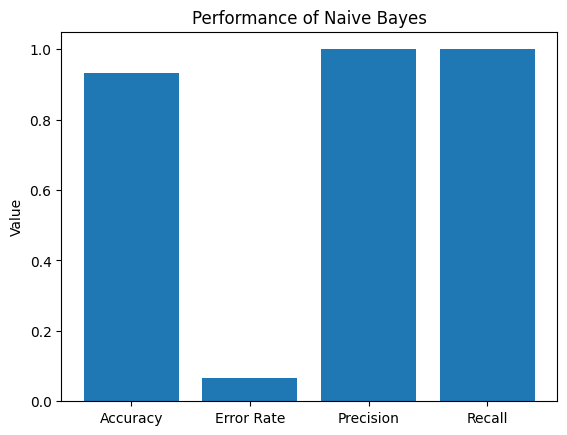

In [23]:
plt.bar(labels, values)
plt.title("Performance of Naive Bayes")
plt.ylabel("Value")
plt.show()